In [71]:
from PIL import Image

# Replace with your image path
image_path = r"C:\Users\david\Downloads\6021840944573301221.jpg"
image_path = r"C:\Users\david\Downloads\141341f5-549f-4f6d-a35a-81f137f268c1.jpeg"
image_path = r"C:\Users\david\Downloads\5776179415221388222.jpg"

# Open the image
image = Image.open(image_path)

# Optional: show it or print its type
print(f"Image size: {image.size}")
print(f"Image mode: {image.mode}")
image.show()


Image size: (1667, 1920)
Image mode: RGB


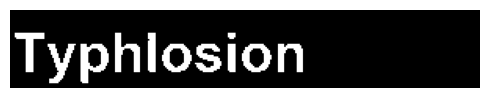

(19, 25)


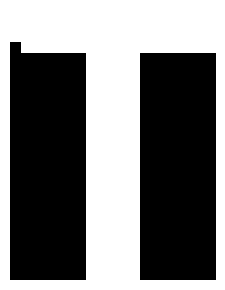

(18, 25)


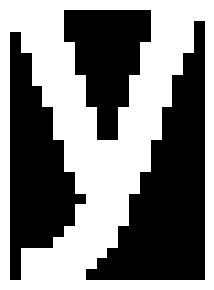

(18, 25)


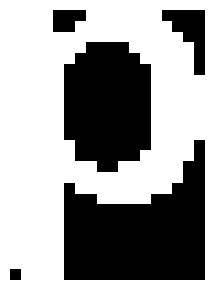

(16, 25)


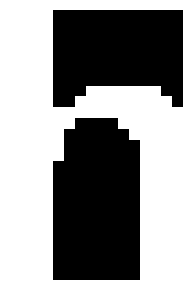

(5, 25)


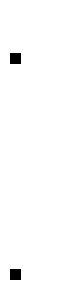

(19, 18)


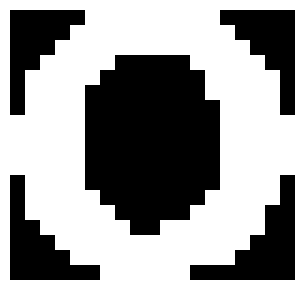

(17, 18)


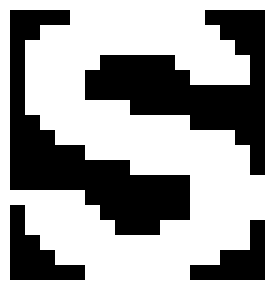

(5, 25)


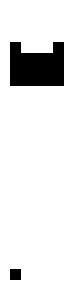

(19, 18)


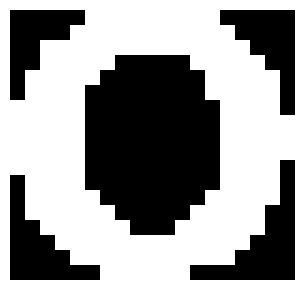

(16, 18)


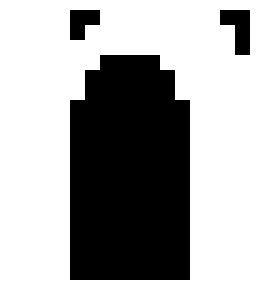

Saved: output_splits\00split_1.png
Saved: output_splits\00split_2.png
Saved: output_splits\00split_3.png
Saved: output_splits\00split_4.png
Saved: output_splits\00split_5.png
Saved: output_splits\00split_6.png
Saved: output_splits\00split_7.png
Saved: output_splits\00split_8.png
Saved: output_splits\00split_9.png
Saved: output_splits\00split_10.png


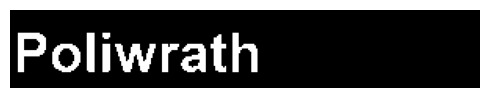

(18, 25)


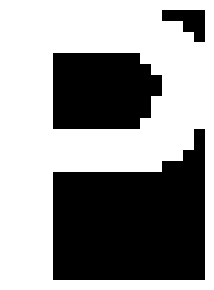

(18, 18)


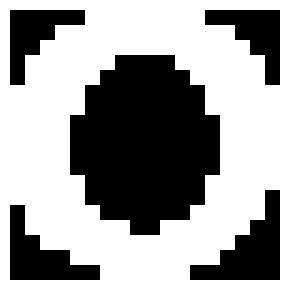

(5, 25)


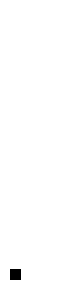

(5, 25)


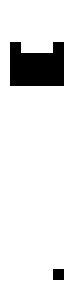

(26, 18)


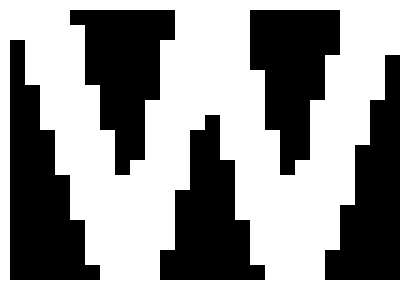

(11, 18)


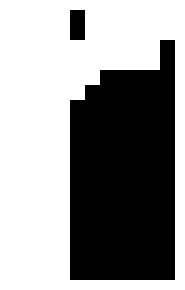

(16, 18)


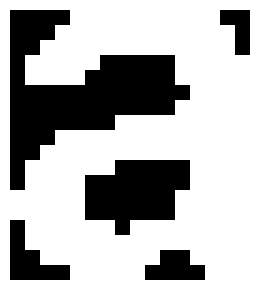

(10, 24)


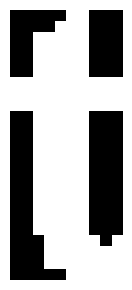

(16, 25)


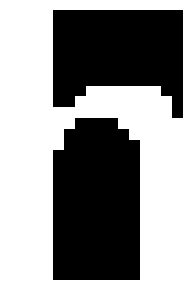

Saved: output_splits\01split_1.png
Saved: output_splits\01split_2.png
Saved: output_splits\01split_3.png
Saved: output_splits\01split_4.png
Saved: output_splits\01split_5.png
Saved: output_splits\01split_6.png
Saved: output_splits\01split_7.png
Saved: output_splits\01split_8.png
Saved: output_splits\01split_9.png


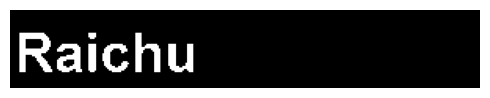

(21, 25)


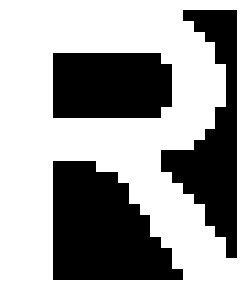

(16, 18)


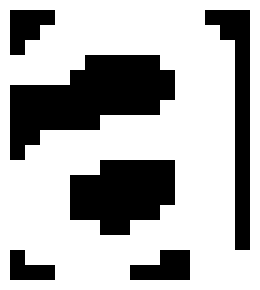

(5, 25)


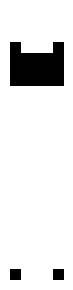

(17, 18)


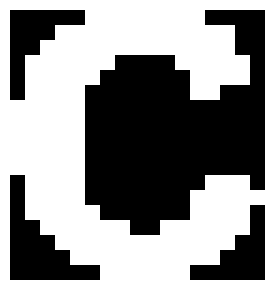

(16, 25)


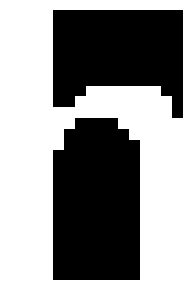

(16, 18)


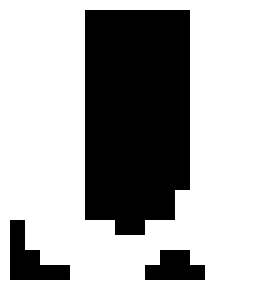

Saved: output_splits\02split_1.png
Saved: output_splits\02split_2.png
Saved: output_splits\02split_3.png
Saved: output_splits\02split_4.png
Saved: output_splits\02split_5.png
Saved: output_splits\02split_6.png


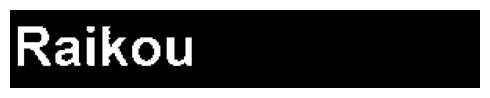

(21, 25)


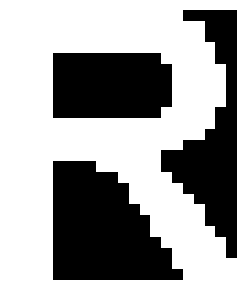

(16, 18)


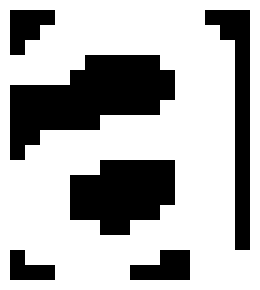

(5, 25)


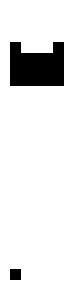

(16, 25)


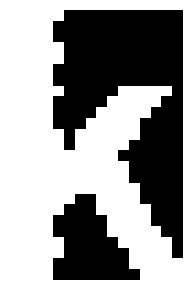

(18, 18)


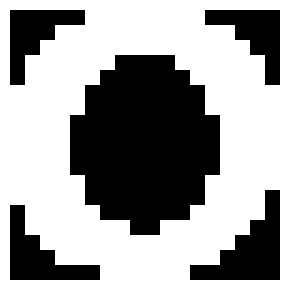

(16, 18)


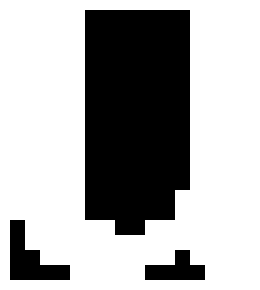

Saved: output_splits\10split_1.png
Saved: output_splits\10split_2.png
Saved: output_splits\10split_3.png
Saved: output_splits\10split_4.png
Saved: output_splits\10split_5.png
Saved: output_splits\10split_6.png


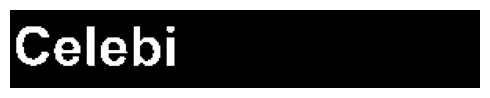

(21, 25)


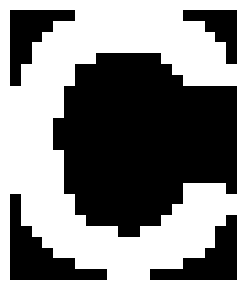

(17, 18)


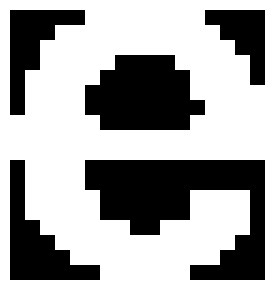

(5, 25)


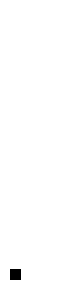

(17, 18)


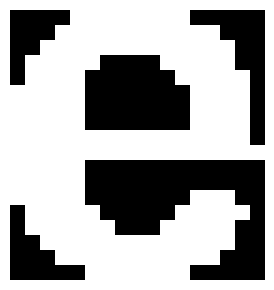

(17, 25)


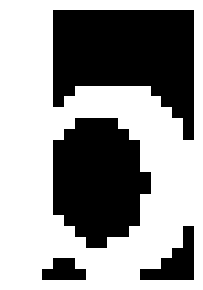

(5, 25)


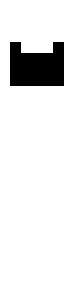

Saved: output_splits\11split_1.png
Saved: output_splits\11split_2.png
Saved: output_splits\11split_3.png
Saved: output_splits\11split_4.png
Saved: output_splits\11split_5.png
Saved: output_splits\11split_6.png


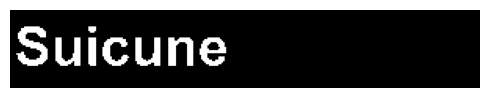

(20, 25)


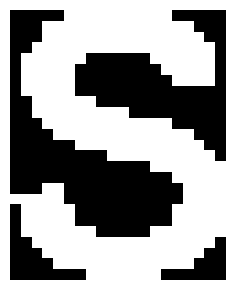

(16, 18)


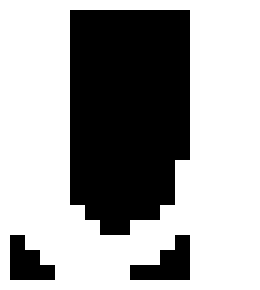

(5, 25)


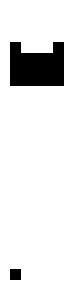

(17, 18)


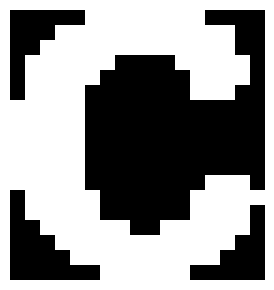

(16, 18)


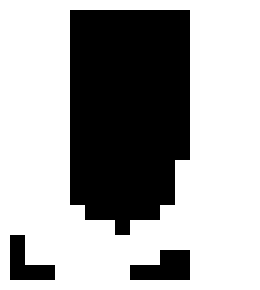

(16, 18)


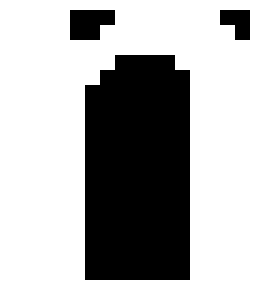

(17, 18)


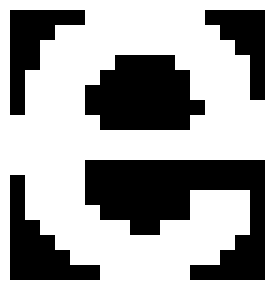

Saved: output_splits\12split_1.png
Saved: output_splits\12split_2.png
Saved: output_splits\12split_3.png
Saved: output_splits\12split_4.png
Saved: output_splits\12split_5.png
Saved: output_splits\12split_6.png
Saved: output_splits\12split_7.png


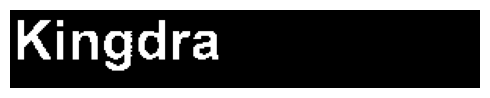

(21, 25)


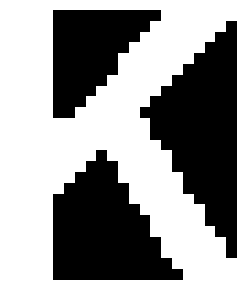

(4, 25)


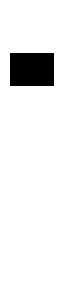

(16, 18)


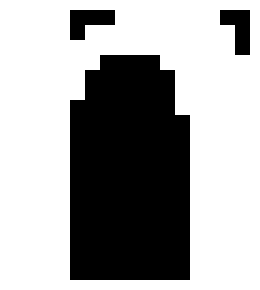

(18, 25)


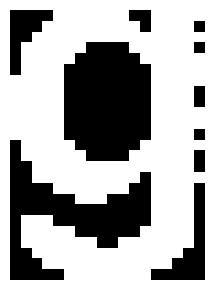

(17, 25)


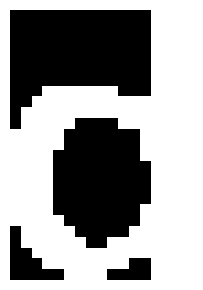

(11, 18)


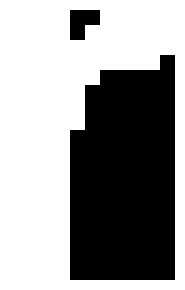

(16, 18)


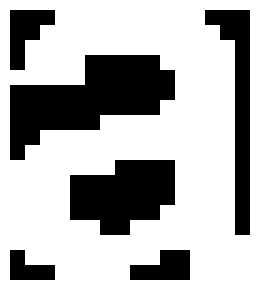

Saved: output_splits\20split_1.png
Saved: output_splits\20split_2.png
Saved: output_splits\20split_3.png
Saved: output_splits\20split_4.png
Saved: output_splits\20split_5.png
Saved: output_splits\20split_6.png
Saved: output_splits\20split_7.png


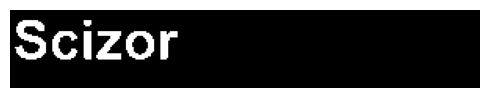

(20, 25)


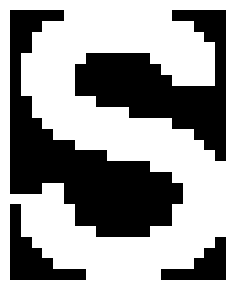

(16, 18)


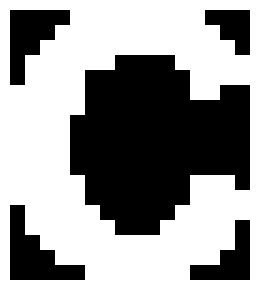

(5, 25)


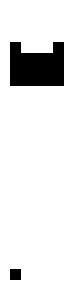

(16, 18)


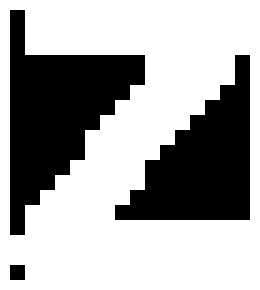

(18, 18)


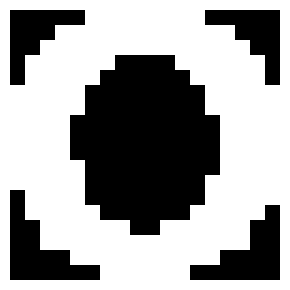

(11, 18)


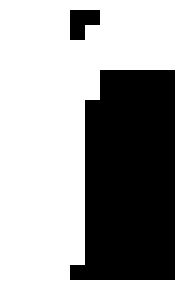

Saved: output_splits\21split_1.png
Saved: output_splits\21split_2.png
Saved: output_splits\21split_3.png
Saved: output_splits\21split_4.png
Saved: output_splits\21split_5.png
Saved: output_splits\21split_6.png


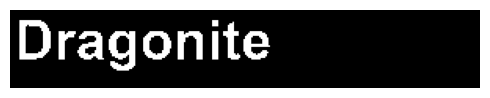

(20, 25)


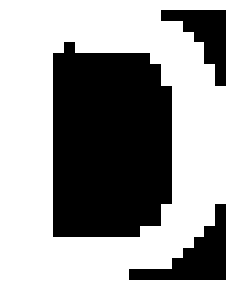

(11, 18)


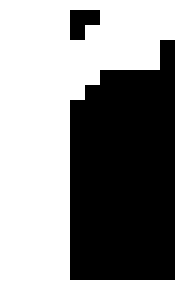

(17, 18)


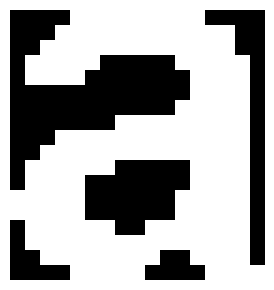

(17, 25)


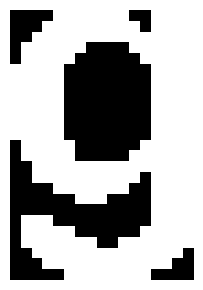

(18, 18)


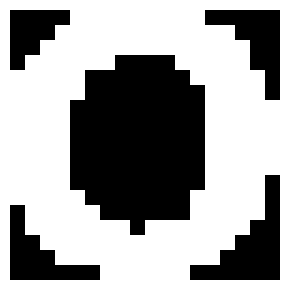

(16, 18)


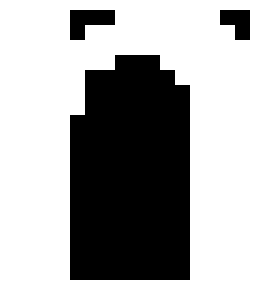

(4, 25)


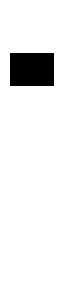

(11, 24)


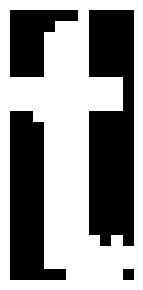

(17, 18)


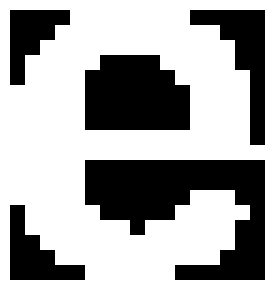

Saved: output_splits\22split_1.png
Saved: output_splits\22split_2.png
Saved: output_splits\22split_3.png
Saved: output_splits\22split_4.png
Saved: output_splits\22split_5.png
Saved: output_splits\22split_6.png
Saved: output_splits\22split_7.png
Saved: output_splits\22split_8.png
Saved: output_splits\22split_9.png
Result: <PIL.Image.Image image mode=RGB size=300x50 at 0x189006DBB50>


In [ ]:
import matplotlib.pyplot as plt

def debug_show_crop(crop, cols=3):
    plt.figure(figsize=(5, 3))
    plt.imshow(crop)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def crop_to_binary(crop, threshold=69):
    gray = crop.convert("L")
    binary = gray.point(lambda p: 1 if p < threshold else 0, mode='1')
    #binary_pixels = list(binary.getdata())
    return binary

import numpy as np

from PIL import Image
import numpy as np

def find_vertical_black_lines(image):
    img_array = np.array(image)
    height, width = img_array.shape
    vertical_lines = []
    # Check each column - if all pixels are 0 (black), it's a vertical black line
    for x in range(width):
        column = img_array[:, x]
        if np.all(column == 0):  # All pixels are black
            vertical_lines.append(x)
    
    return vertical_lines

def find_horizontal_black_lines(image):
    # Convert to binary array (0 = black, 255 = white)
    img_array = np.array(image)
    height, width = img_array.shape
    
    horizontal_lines = []
    
    # Check from top (y=0) going down
    for y in range(height):
        row = img_array[y, :]
        if np.all(row == 0):  # All pixels are black
            horizontal_lines.append(y)
        else:
            break  # Stop at first non-black row
    
    # Check from bottom (y=height-1) going up
    for y in range(height - 1, -1, -1):
        if y in horizontal_lines:
            break  # Already found this row from top scan
        row = img_array[y, :]
        if np.all(row == 0):  # All pixels are black
            horizontal_lines.append(y)
        else:
            break  # Stop at first non-black row
    
    return sorted(horizontal_lines)

def split_image_by_vertical_lines(image, vertical_lines):
    if not vertical_lines:
        return [image]
    width, height = image.size
    sub_images = []
    vertical_lines = sorted(set(vertical_lines))     # Sort vertical lines and remove duplicates
    line_groups = [] # Group consecutive vertical lines together
    current_group = [vertical_lines[0]]
    for i in range(1, len(vertical_lines)):
        if vertical_lines[i] == vertical_lines[i-1] + 1:
            current_group.append(vertical_lines[i])
        else:
            line_groups.append(current_group)
            current_group = [vertical_lines[i]]
    line_groups.append(current_group)
    split_points = [0]
    for group in line_groups:
        split_points.append(group[-1] + 1)  # After the last line in the group
    split_points.append(width)
    for i in range(len(split_points) - 1):
        left = split_points[i]
        right = split_points[i + 1]
        if right - left > 0:         # Skip if the section is empty or too narrow
            sub_image = image.crop((left, 0, right, height))
            sub_images.append(sub_image)
    return sub_images

def remove_black_lines_from_image(image):
    vertical_lines = find_vertical_black_lines(image)
    horizontal_lines = find_horizontal_black_lines(image)  
    if not vertical_lines and not horizontal_lines:
        return image
    width, height = image.size
    keep_columns = [x for x in range(width) if x not in vertical_lines]
    keep_rows = [y for y in range(height) if y not in horizontal_lines]
    if not keep_columns or not keep_rows:
        return Image.new('1', (1, 1), 1)
    new_width, new_height = len(keep_columns), len(keep_rows)
    new_image = Image.new('1', (new_width, new_height), 1)  # White background
    for new_y, old_y in enumerate(keep_rows):
        for new_x, old_x in enumerate(keep_columns):
            pixel = image.getpixel((old_x, old_y))
            new_image.putpixel((new_x, new_y), pixel)
    return new_image

def process_image_to_remove_black(image):
    vertical_lines = find_vertical_black_lines(image)
    sub_images = split_image_by_vertical_lines(image, vertical_lines)
    cleaned_images = []
    for i, sub_img in enumerate(sub_images):    
        cleaned_img = remove_black_lines_from_image(sub_img)
        if cleaned_img and cleaned_img.size != (1,1):
            cleaned_images.append(cleaned_img)    
    return cleaned_images
    
async def automatic_card_reader(image):
    width, height = image.size

    # Estrai i nomi:
    name_boxes = []
    box_width = 300
    box_height = 50

    for row in range(3):
        for col in range(3):
            left = 596 + col * 345
            upper = 50 + row * 618
            right = left + box_width
            lower = upper + box_height
            name_crop = image.crop((left, upper, right, lower))
            binary_img = crop_to_binary(name_crop)
            
            splits = process_image_to_remove_black(binary_img)
            
            debug_show_crop(binary_img)
            for s in splits:
                print(s.size)
                debug_show_crop(s)

            # import os
            # def save_binary_images(images, output_dir="output_splits", prefix="split"):
            #     os.makedirs(output_dir, exist_ok=True)
            
            #     for i, img in enumerate(images):
            #         path = os.path.join(output_dir, f"{row}{col}{prefix}_{i+1}.png")
            #         img.save(path)
            #         print(f"Saved: {path}")
            # save_binary_images(splits)
                               
    return name_crop

dic = await automatic_card_reader(image)
print(f"Result: {dic}")

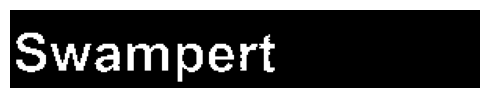

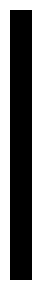

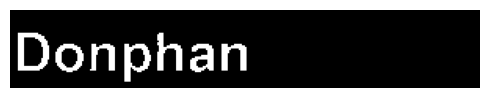

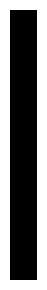

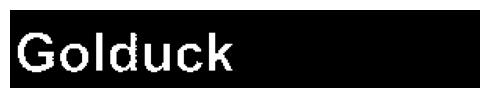

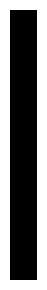

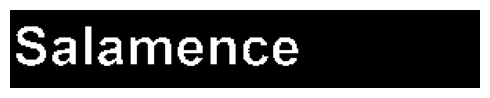

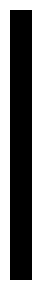

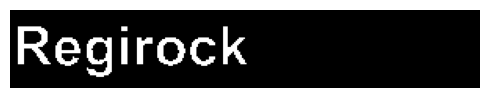

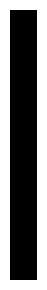

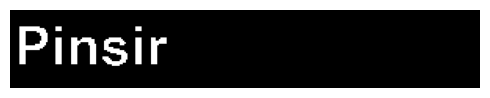

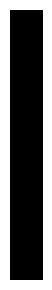

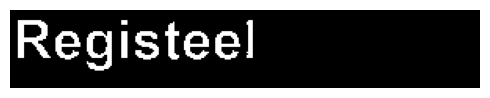

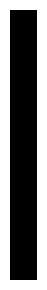

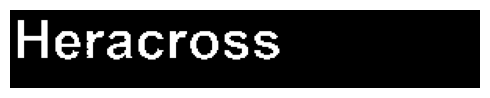

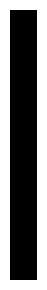

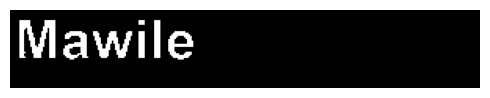

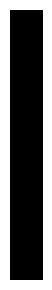

Result: <PIL.Image.Image image mode=RGB size=300x50 at 0x1897EA71610>

📊 Performance:
⏱️  Time: 0.928s
🧠 Peak Memory: 2.5MB
💾 Memory Used: 1.5MB


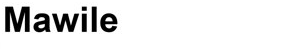

In [39]:
import time
import tracemalloc

# Simple measurement - just replace your current lines with this
async def measure_function_execution():
    # Start measurements
    start_time = time.perf_counter()
    tracemalloc.start()
    
    try:
        # YOUR FUNCTION CALL
        dic = await automatic_card_reader(image)
        print(f"Result: {dic}")
        
    finally:
        # Get metrics
        end_time = time.perf_counter()
        current_memory, peak_memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        
        # Show 3 most important metrics
        print(f"\n📊 Performance:")
        print(f"⏱️  Time: {end_time - start_time:.3f}s")
        print(f"🧠 Peak Memory: {peak_memory / 1024 / 1024:.1f}MB") 
        print(f"💾 Memory Used: {current_memory / 1024 / 1024:.1f}MB")
        
    return dic

await measure_function_execution()    